In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    precision_recall_curve, roc_curve,
    confusion_matrix, f1_score
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# Load cleaned dataset
df = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/secom_selected_features.csv'
)
df = df.sort_values('timestamp').reset_index(drop=True)

# Load risk scores from Notebook 3
risk_scores = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/wafer_risk_scores.csv'
)

# Load trained model pipeline and scaler
pipeline = joblib.load(
    '/home/jupyter/secom-yield-optimization/models/logistic_regression_pipeline.pkl'
)
scaler = joblib.load(
    '/home/jupyter/secom-yield-optimization/models/scaler.pkl'
)

# Reconstruct train/test split — same as Notebook 3
feature_cols = [c for c in df.columns if c.startswith('sensor_')]
X = df[feature_cols]
y = df['label']

split_idx   = int(len(df) * 0.80)
X_train     = X.iloc[:split_idx]
X_test      = X.iloc[split_idx:]
y_train     = y.iloc[:split_idx]
y_test      = y.iloc[split_idx:]

# Get failure probabilities for test set
y_pred_prob = pipeline.predict_proba(X_test)[:, 1]

print(f"Data loaded")
print(f"Test set: {len(y_test)} wafers | {y_test.sum()} failures")
print(f"Risk scores loaded: {len(risk_scores)} wafers")

Data loaded
Test set: 314 wafers | 20 failures
Risk scores loaded: 314 wafers


In [3]:
# Cost structure for a semiconductor fab
# These are realistic relative costs — actual values are fab-specific
# All costs in arbitrary units (could be $thousands per wafer)

COST_MISSED_FAILURE = 100   # Cost of missing a failing wafer
                             # Full processing cost + scrap cost
                             # + potential downstream damage

COST_FALSE_ALARM    = 5     # Cost of flagging a good wafer unnecessarily
                             # Engineering review time + potential rework delay
                             # Much cheaper than a missed failure

# Ratio tells us how conservative to be
cost_ratio = COST_MISSED_FAILURE / COST_FALSE_ALARM
print(f"Cost structure defined")
print(f"\nCost of missed failure:  {COST_MISSED_FAILURE} units")
print(f"Cost of false alarm:     {COST_FALSE_ALARM} units")
print(f"Cost ratio:              {cost_ratio:.1f}x")

Cost structure defined

Cost of missed failure:  100 units
Cost of false alarm:     5 units
Cost ratio:              20.0x


In [4]:
# Sweep across all possible decision thresholds
# For each threshold, calculate the total cost
precision_vals, recall_vals, thresholds = precision_recall_curve(
    y_test, y_pred_prob
)


thresholds = np.append(thresholds, 1.0)

total_costs    = []
false_alarms   = []
missed_failures = []
caught_failures = []

for threshold in thresholds:
    # Apply threshold to get predictions
    y_pred_t = (y_pred_prob >= threshold).astype(int)
    
    # Calculate confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(
        y_test, y_pred_t, labels=[0, 1]
    ).ravel()
    
    # Total cost = cost of missed failures + cost of false alarms
    total_cost = (fn * COST_MISSED_FAILURE) + (fp * COST_FALSE_ALARM)
    
    total_costs.append(total_cost)
    false_alarms.append(fp)
    missed_failures.append(fn)
    caught_failures.append(tp)

# Find threshold that minimizes total cost
optimal_idx       = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_idx]
optimal_cost      = total_costs[optimal_idx]

print(f"Threshold optimization complete")
print(f"\nOptimal threshold:      {optimal_threshold:.4f}")
print(f"Total cost at optimal:  {optimal_cost:.0f} units")
print(f"Missed failures:        {missed_failures[optimal_idx]}")
print(f"False alarms:           {false_alarms[optimal_idx]}")
print(f"Failures caught:        {caught_failures[optimal_idx]}/{y_test.sum()}")
print(f"\nDefault threshold (0.5) performance:")
default_idx = np.argmin(np.abs(thresholds - 0.5))
print(f"Total cost:             {total_costs[default_idx]:.0f} units")
print(f"Missed failures:        {missed_failures[default_idx]}")
print(f"False alarms:           {false_alarms[default_idx]}")
print(f"Failures caught:        {caught_failures[default_idx]}/{y_test.sum()}")

Threshold optimization complete

Optimal threshold:      0.2828
Total cost at optimal:  1040 units
Missed failures:        4
False alarms:           128
Failures caught:        16/20

Default threshold (0.5) performance:
Total cost:             1220 units
Missed failures:        9
False alarms:           64
Failures caught:        11/20


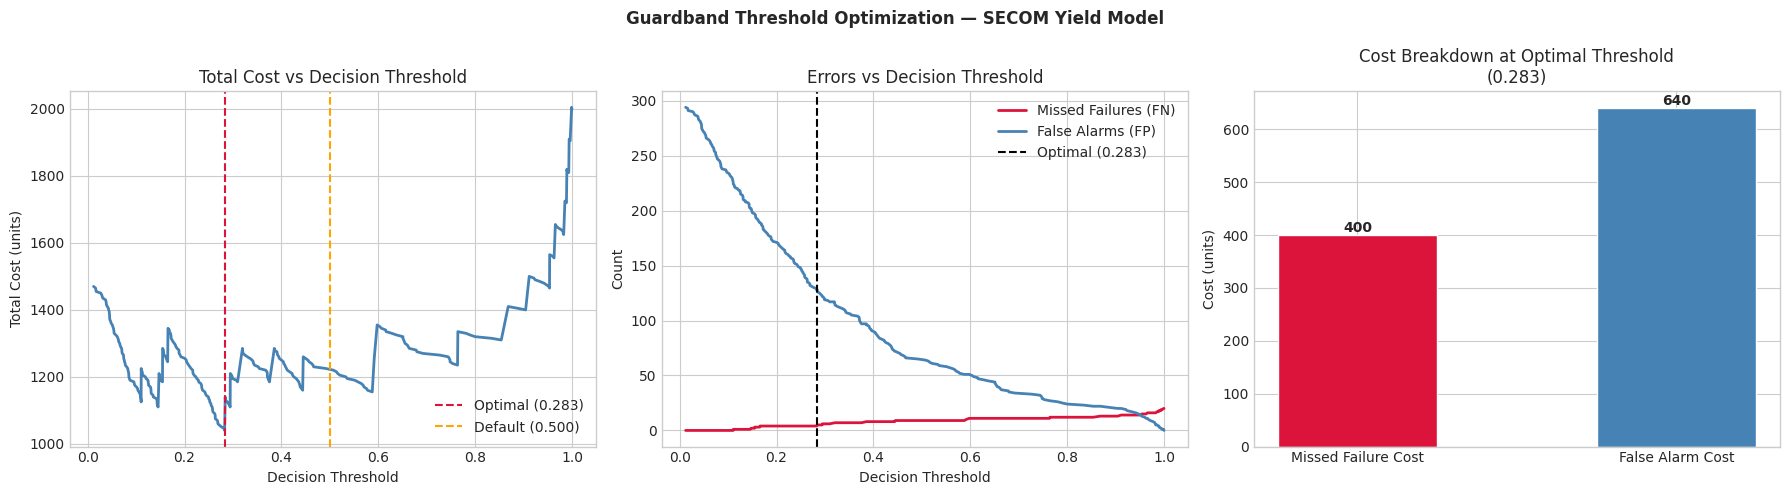

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Total cost vs threshold
axes[0].plot(thresholds, total_costs, color='steelblue', linewidth=2)
axes[0].axvline(x=optimal_threshold, color='crimson', linestyle='--',
                label=f'Optimal ({optimal_threshold:.3f})')
axes[0].axvline(x=0.5, color='orange', linestyle='--',
                label='Default (0.500)')
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Total Cost (units)')
axes[0].set_title('Total Cost vs Decision Threshold')
axes[0].legend()

# Middle: Missed failures and false alarms vs threshold
axes[1].plot(thresholds, missed_failures, color='crimson',
             linewidth=2, label='Missed Failures (FN)')
axes[1].plot(thresholds, false_alarms, color='steelblue',
             linewidth=2, label='False Alarms (FP)')
axes[1].axvline(x=optimal_threshold, color='black', linestyle='--',
                label=f'Optimal ({optimal_threshold:.3f})')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Count')
axes[1].set_title('Errors vs Decision Threshold')
axes[1].legend()

# Right: Cost breakdown at optimal threshold
categories = ['Missed Failure Cost', 'False Alarm Cost']
costs = [
    missed_failures[optimal_idx] * COST_MISSED_FAILURE,
    false_alarms[optimal_idx]    * COST_FALSE_ALARM
]
colors = ['crimson', 'steelblue']
axes[2].bar(categories, costs, color=colors, edgecolor='white', width=0.5)
axes[2].set_ylabel('Cost (units)')
axes[2].set_title(f'Cost Breakdown at Optimal Threshold\n'
                  f'({optimal_threshold:.3f})')
for i, cost in enumerate(costs):
    axes[2].text(i, cost + 5, str(cost), ha='center', fontweight='bold')

plt.suptitle('Guardband Threshold Optimization — SECOM Yield Model',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/home/jupyter/secom-yield-optimization/data/processed/threshold_optimization.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

In [6]:
# For each of our top features, calculate guardbands based on
# the distribution of passing wafers in the training set
# Guardband = value beyond which a wafer looks more like a failure

# Get training set passing wafers only
# fit guardbands on pass distribution — the "normal" process state
train_df = df.iloc[:split_idx].copy()
pass_train = train_df[train_df['label'] == 0]
fail_train = train_df[train_df['label'] == 1]

# Load feature selection results to get top features
feature_results = pd.read_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/feature_selection_results.csv'
)

# Focus on Tier 1 features — highest confidence
tier1_features = feature_results[
    feature_results['tier'] == 'Tier 1 (High Confidence)'
]['sensor'].tolist()

print(f"Designing guardbands for {len(tier1_features)} Tier 1 features")
print(f"Features: {tier1_features}\n")

guardband_results = []

for sensor in tier1_features:
    pass_vals = pass_train[sensor]
    fail_vals = fail_train[sensor]
    
    # Pass distribution statistics
    pass_mean = pass_vals.mean()
    pass_std  = pass_vals.std()
    pass_p01  = pass_vals.quantile(0.01)   # 1st percentile
    pass_p99  = pass_vals.quantile(0.99)   # 99th percentile
    
    # Fail distribution statistics
    fail_mean = fail_vals.mean()
    fail_p50  = fail_vals.median()
    
    # Guardband limits — set at 99th/1st percentile of passing distribution
    # Conservative: only 1% of passing wafers would trigger a false alarm
    # purely from this sensor alone
    gb_lower = pass_p01
    gb_upper = pass_p99
    
    # Direction of failure risk
    # If fail mean > pass mean → failures tend to have higher values
    # If fail mean < pass mean → failures tend to have lower values
    if fail_mean > pass_mean:
        risk_direction = 'High values → failure risk'
    else:
        risk_direction = 'Low values → failure risk'
    
    # Separation score — how well does this sensor separate pass from fail?
    # Higher = better separation = more useful guardband
    separation = abs(fail_mean - pass_mean) / pass_std

    guardband_results.append({
        'sensor':          sensor,
        'pass_mean':       pass_mean,
        'pass_std':        pass_std,
        'fail_mean':       fail_mean,
        'gb_lower':        gb_lower,
        'gb_upper':        gb_upper,
        'risk_direction':  risk_direction,
        'separation_score': separation
    })

gb_df = pd.DataFrame(guardband_results).sort_values(
    'separation_score', ascending=False
)

print("Guardband Design Results:")
print(gb_df[['sensor', 'pass_mean', 'fail_mean', 
             'gb_lower', 'gb_upper', 
             'separation_score', 'risk_direction']].to_string(index=False))

Designing guardbands for 16 Tier 1 features
Features: ['sensor_60', 'sensor_22', 'sensor_478', 'sensor_122', 'sensor_130', 'sensor_511', 'sensor_337', 'sensor_349', 'sensor_282', 'sensor_15', 'sensor_426', 'sensor_201', 'sensor_34', 'sensor_131', 'sensor_317', 'sensor_334']

Guardband Design Results:
    sensor  pass_mean  fail_mean   gb_lower   gb_upper  separation_score             risk_direction
sensor_478     5.6067     7.0837     2.2442    14.7374            0.6637 High values → failure risk
 sensor_60     2.6392     7.8945   -11.9682    28.3121            0.6395 High values → failure risk
sensor_511    54.2800    74.1794    18.0064   201.4363            0.6379 High values → failure risk
sensor_349     0.0244     0.0291     0.0116     0.0627            0.5192 High values → failure risk
sensor_130    -0.5083     0.0629    -3.7320     1.6550            0.4640 High values → failure risk
 sensor_22 -5644.9593 -5419.4545 -6618.4800 -4217.9200            0.4214 High values → failure ris

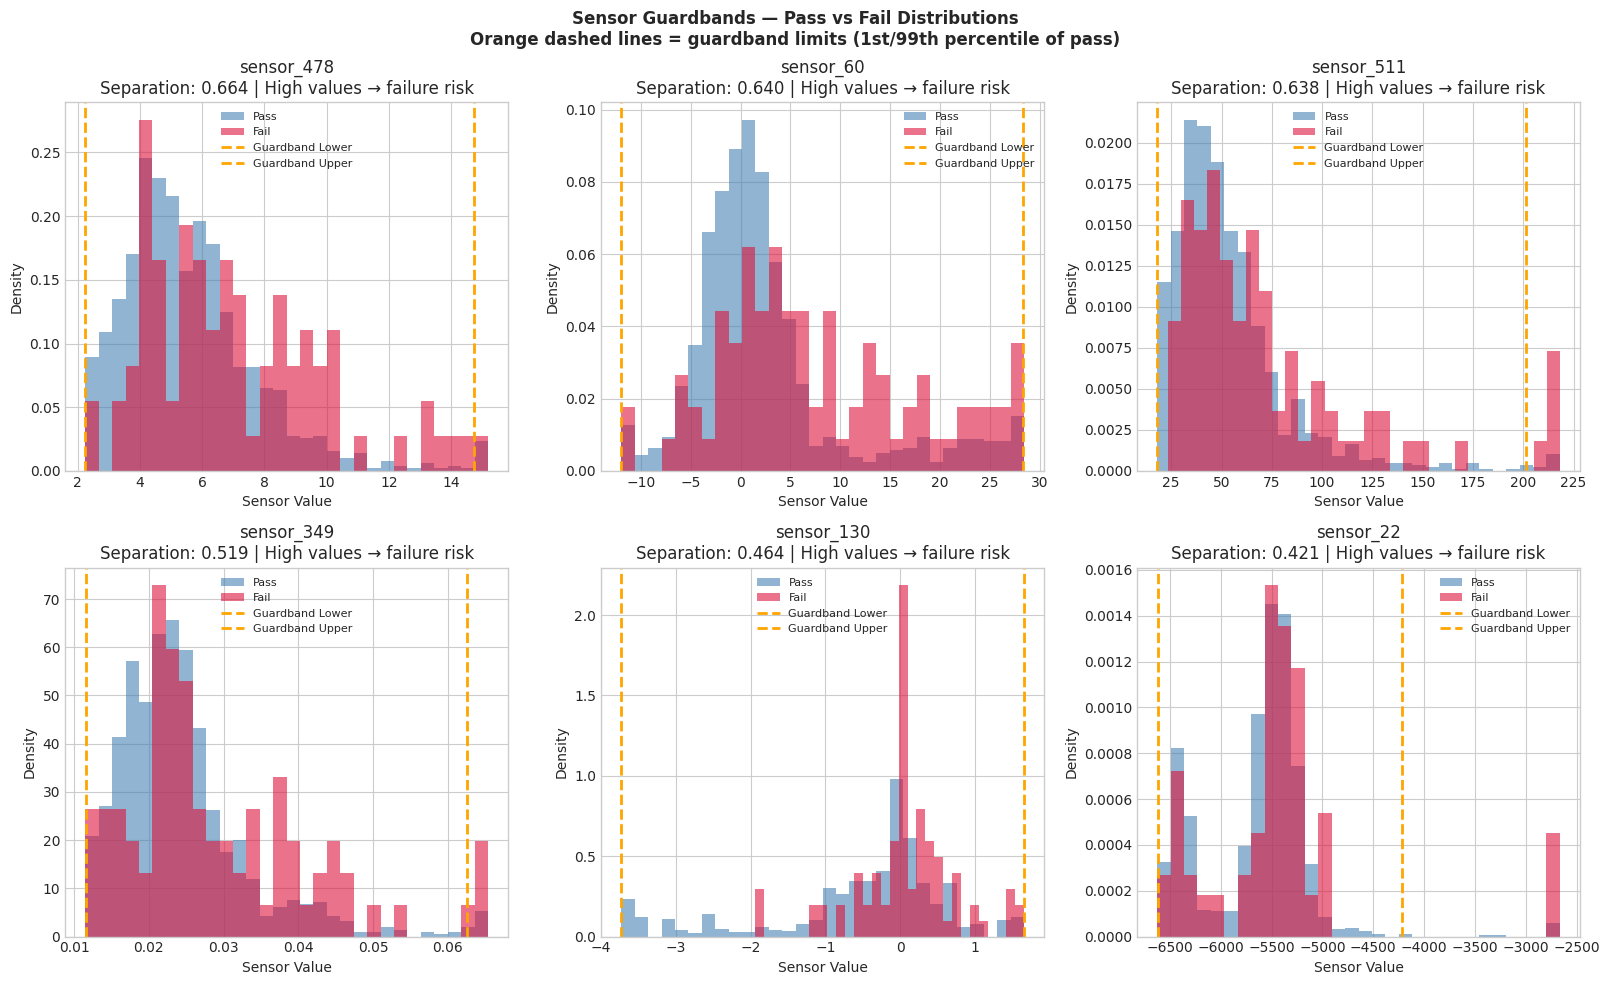

In [7]:
top6 = gb_df.head(6)['sensor'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, sensor in enumerate(top6):
    ax = axes[idx]
    
    pass_vals = pass_train[sensor]
    fail_vals = fail_train[sensor]
    gb_row    = gb_df[gb_df['sensor'] == sensor].iloc[0]
    
    # Plot pass and fail distributions
    ax.hist(pass_vals, bins=30, alpha=0.6, 
            color='steelblue', label='Pass', density=True)
    ax.hist(fail_vals, bins=30, alpha=0.6,
            color='crimson',  label='Fail', density=True)
    
    # Plot guardband limits as vertical lines
    ax.axvline(x=gb_row['gb_lower'], color='orange', 
               linestyle='--', linewidth=2, label='Guardband Lower')
    ax.axvline(x=gb_row['gb_upper'], color='orange',
               linestyle='--', linewidth=2, label='Guardband Upper')
    
    ax.set_title(f"{sensor}\n"
                 f"Separation: {gb_row['separation_score']:.3f} | "
                 f"{gb_row['risk_direction']}")
    ax.set_xlabel('Sensor Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Sensor Guardbands — Pass vs Fail Distributions\n'
             'Orange dashed lines = guardband limits (1st/99th percentile of pass)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(
    '/home/jupyter/secom-yield-optimization/data/processed/sensor_guardbands.png',
    dpi=150, bbox_inches='tight'
)
plt.show()


In [8]:
# Define intervention policy based on optimized threshold
# and risk categories

# We use the optimal threshold (0.2828) as the trigger point
# and build tiers around it

policy = {
    'Low Risk': {
        'prob_range':  (0.00, 0.15),
        'action':      'Normal processing',
        'inspection':  'Standard end-of-line inspection',
        'frequency':   'None',
        'urgency':     'Routine'
    },
    'Medium Risk': {
        'prob_range':  (0.15, 0.2828),
        'action':      'Enhanced monitoring',
        'inspection':  'Flag for engineer review within 4 hours',
        'frequency':   'Increased SPC sampling',
        'urgency':     'Monitor'
    },
    'High Risk': {
        'prob_range':  (0.2828, 0.60),
        'action':      'Engineering review required',
        'inspection':  'Pull for inspection before next process step',
        'frequency':   'Real-time sensor monitoring',
        'urgency':     'Urgent'
    },
    'Critical Risk': {
        'prob_range':  (0.60, 1.00),
        'action':      'Hold wafer — immediate intervention',
        'inspection':  'Full diagnostic before processing continues',
        'frequency':   'Continuous monitoring',
        'urgency':     'Critical'
    }
}

# Apply policy to test set
def assign_policy(prob):
    if prob < 0.15:
        return 'Low Risk'
    elif prob < 0.2828:
        return 'Medium Risk'
    elif prob < 0.60:
        return 'High Risk'
    else:
        return 'Critical Risk'

risk_scores['policy_tier'] = risk_scores['failure_prob'].apply(assign_policy)

# Analyze actual failure rates by policy tier
print("Intervention Policy — Actual Performance on Test Set:")
print("=" * 75)
print(f"{'Tier':<15} {'Wafers':>7} {'Failures':>9} {'Fail Rate':>10} "
      f"{'Action':<35}")
print("-" * 75)

tier_order = ['Low Risk', 'Medium Risk', 'High Risk', 'Critical Risk']
for tier in tier_order:
    subset = risk_scores[risk_scores['policy_tier'] == tier]
    if len(subset) > 0:
        n_wafers   = len(subset)
        n_failures = subset['actual_label'].sum()
        fail_rate  = n_failures / n_wafers * 100
        action     = policy[tier]['action']
        print(f"{tier:<15} {n_wafers:>7} {n_failures:>9} "
              f"{fail_rate:>9.1f}% {action:<35}")

print("=" * 75)

# Show urgency and inspection details
print("\nDetailed Policy Actions:")
for tier in tier_order:
    p = policy[tier]
    print(f"\n{tier} ({p['prob_range'][0]:.2f} - {p['prob_range'][1]:.4f}):")
    print(f"  Action:     {p['action']}")
    print(f"  Inspection: {p['inspection']}")
    print(f"  Urgency:    {p['urgency']}")

Intervention Policy — Actual Performance on Test Set:
Tier             Wafers  Failures  Fail Rate Action                             
---------------------------------------------------------------------------
Low Risk             98         2       2.0% Normal processing                  
Medium Risk          72         2       2.8% Enhanced monitoring                
High Risk            85         7       8.2% Engineering review required        
Critical Risk        59         9      15.3% Hold wafer — immediate intervention

Detailed Policy Actions:

Low Risk (0.00 - 0.1500):
  Action:     Normal processing
  Inspection: Standard end-of-line inspection
  Urgency:    Routine

Medium Risk (0.15 - 0.2828):
  Action:     Enhanced monitoring
  Inspection: Flag for engineer review within 4 hours
  Urgency:    Monitor

High Risk (0.28 - 0.6000):
  Action:     Engineering review required
  Inspection: Pull for inspection before next process step
  Urgency:    Urgent

Critical Risk (0.60 -

In [9]:
# Calculate the economic value of the guardband system
# Compare: no model vs model with optimal threshold

print("=" * 60)
print("COST-BENEFIT ANALYSIS")
print("=" * 60)

n_test_wafers  = len(y_test)
n_failures     = y_test.sum()
n_passes       = (y_test == 0).sum()

# Scenario 1: No model (baseline)
# All failures are missed — discovered at end of line
baseline_cost  = n_failures * COST_MISSED_FAILURE
print(f"\nScenario 1: No Model (Baseline)")
print(f"  All {n_failures} failures discovered at end of line")
print(f"  Total cost: {baseline_cost} units")

# Scenario 2: Default threshold (0.5)
y_pred_default    = (y_pred_prob >= 0.50).astype(int)
tn, fp, fn, tp    = confusion_matrix(y_test, y_pred_default).ravel()
default_cost      = (fn * COST_MISSED_FAILURE) + (fp * COST_FALSE_ALARM)
default_savings   = baseline_cost - default_cost
print(f"\nScenario 2: Model with Default Threshold (0.5)")
print(f"  Caught: {tp}/20 failures | Missed: {fn} | False alarms: {fp}")
print(f"  Total cost:    {default_cost} units")
print(f"  Savings vs baseline: {default_savings} units "
      f"({default_savings/baseline_cost*100:.1f}%)")

# Scenario 3: Optimal threshold (0.2828)
y_pred_optimal    = (y_pred_prob >= optimal_threshold).astype(int)
tn, fp, fn, tp    = confusion_matrix(y_test, y_pred_optimal).ravel()
optimal_cost      = (fn * COST_MISSED_FAILURE) + (fp * COST_FALSE_ALARM)
optimal_savings   = baseline_cost - optimal_cost
print(f"\nScenario 3: Model with Optimal Threshold ({optimal_threshold:.4f})")
print(f"  Caught: {tp}/20 failures | Missed: {fn} | False alarms: {fp}")
print(f"  Total cost:    {optimal_cost} units")
print(f"  Savings vs baseline: {optimal_savings} units "
      f"({optimal_savings/baseline_cost*100:.1f}%)")

# Additional improvement from threshold optimization
additional_savings = optimal_savings - default_savings
print(f"\nValue of threshold optimization over default:")
print(f"  Additional savings: {optimal_savings - default_savings} units")

# Annualized estimate
# SECOM covers ~3 months of production (Jul-Sep 2008)
# Scale to annual
annual_multiplier = 4
print(f"\nAnnualized Projection (×{annual_multiplier} for full year):")
print(f"  Baseline annual cost:      "
      f"{baseline_cost * annual_multiplier} units")
print(f"  With optimal guardband:    "
      f"{optimal_cost * annual_multiplier} units")
print(f"  Annual savings:            "
      f"{optimal_savings * annual_multiplier} units")

COST-BENEFIT ANALYSIS

Scenario 1: No Model (Baseline)
  All 20 failures discovered at end of line
  Total cost: 2000 units

Scenario 2: Model with Default Threshold (0.5)
  Caught: 11/20 failures | Missed: 9 | False alarms: 64
  Total cost:    1220 units
  Savings vs baseline: 780 units (39.0%)

Scenario 3: Model with Optimal Threshold (0.2828)
  Caught: 16/20 failures | Missed: 4 | False alarms: 128
  Total cost:    1040 units
  Savings vs baseline: 960 units (48.0%)

Value of threshold optimization over default:
  Additional savings: 180 units

Annualized Projection (×4 for full year):
  Baseline annual cost:      8000 units
  With optimal guardband:    4160 units
  Annual savings:            3840 units


In [10]:
import subprocess
import os

# Save guardband table
gb_df.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/guardband_limits.csv',
    index=False
)

# Save risk scores with policy tiers
risk_scores.to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/wafer_risk_scores_with_policy.csv',
    index=False
)

# Save policy summary
policy_summary = []
for tier in tier_order:
    subset   = risk_scores[risk_scores['policy_tier'] == tier]
    p        = policy[tier]
    n_wafers = len(subset)
    n_fail   = subset['actual_label'].sum() if len(subset) > 0 else 0
    policy_summary.append({
        'tier':        tier,
        'prob_lower':  p['prob_range'][0],
        'prob_upper':  p['prob_range'][1],
        'action':      p['action'],
        'urgency':     p['urgency'],
        'n_wafers':    n_wafers,
        'n_failures':  n_fail,
        'fail_rate':   n_fail/n_wafers if n_wafers > 0 else 0
    })

pd.DataFrame(policy_summary).to_csv(
    '/home/jupyter/secom-yield-optimization/data/processed/intervention_policy.csv',
    index=False
)

print("Guardband artifacts saved")

# Upload to GCS
files = [
    'data/processed/guardband_limits.csv',
    'data/processed/wafer_risk_scores_with_policy.csv',
    'data/processed/intervention_policy.csv',
    'data/processed/threshold_optimization.png',
    'data/processed/sensor_guardbands.png',
]

base   = '/home/jupyter/secom-yield-optimization/'
bucket = 'gs://secom-data-temi/'

for f in files:
    result = subprocess.run(
        ['gsutil', 'cp', base + f, bucket + f],
        capture_output=True, text=True
    )
    status = "Success!" if result.returncode == 0 else "Failed!"
    print(f"{status} {f}")

Guardband artifacts saved
Success! data/processed/guardband_limits.csv
Success! data/processed/wafer_risk_scores_with_policy.csv
Success! data/processed/intervention_policy.csv
Success! data/processed/threshold_optimization.png
Success! data/processed/sensor_guardbands.png
